# Quantum Statistical Potential

The YAML input file can be found at [input_file](https://raw.githubusercontent.com/murillo-group/sarkas/master/docs/examples/QSP/input_files/QSP_cgs.yaml) and this notebook at [notebook](https://raw.githubusercontent.com/murillo-group/sarkas/master/docs/examples/QSP/QSP_Tutorial.ipynb).

In [1]:
# Import the usual libraries
import numpy as np
import matplotlib.pyplot as plt
import os

plt.style.use('MSUstyle')
# Import sarkas
from sarkas.processes import Simulation, PostProcess, PreProcess

# Create the file path to the YAML input file
input_file_name = os.path.join('input_files',  'QSP_Kelbg.yaml')







________             ______                
__  ___/_____ __________  /_______ ________
_____ \_  __ `/_  ___/_  //_/  __ `/_  ___/
____/ // /_/ /_  /   _  ,<  / /_/ /_(__  ) 
/____/ \__,_/ /_/    /_/|_| \__,_/ /____/  
                                           




An open-source pure-python molecular dynamics suite for non-ideal plasmas.




********************************************************************************
                                 Preprocessing                                  
********************************************************************************

Job ID: qsp_cgs
Job directory: SarkasSimulations/qsp_cgs
PreProcessing directory: 
SarkasSimulations/qsp_cgs/PreProcessing

Equilibration dumps directory: 
SarkasSimulations/qsp_cgs/PreProcessing/Equilibration/dumps
Production dumps directory: 
SarkasSimulations/qsp_cgs/PreProcessing/Production/dumps

Equilibration H5MD file: 
SarkasSimulations/qsp_cgs/PreProcessing/Equilibration/dumps/qsp_cgs_data.h5md
Production H5MD file: 
SarkasSimulations/qsp_cgs/PreProcessing/Production/dumps/qsp_cgs_data.h5md

PARTICLES:
Total No. of particles = 16384
No. of species = 2
Species ID: 0
	Name: e
	No. of particles = 8192
	Number density = 5.979000e+23 [N/cc]
	Atomic weight = 5.4461

PP acceleration timer:   0%|          | 0/11 [00:00<?, ?it/s]

Time of PP acceleration calculation averaged over 10 steps:
0 min 0 sec 565 msec 672 usec 795 nsec 



PM acceleration timer:   0%|          | 0/11 [00:00<?, ?it/s]

Time of PM acceleration calculation averaged over 10 steps:
0 min 0 sec 250 msec 641 usec 119 nsec 



  0%|          | 0/11 [00:00<?, ?it/s]

Time of a single Equilibration step averaged over 10 steps:
0 min 0 sec 830 msec 559 usec 968 nsec 



  0%|          | 0/11 [00:00<?, ?it/s]

Time of a single Production step averaged over 10 steps:
0 min 0 sec 801 msec 529 usec 571 nsec 



----------------------- Total Estimated Times ------------------------ 


Equilibration Time: 0 hrs 55 min 22 sec

Production Time: 0 hrs 26 min 43 sec

Total Run Time: 1 hrs 22 min 5 sec


========================= Filesize Estimates =========================

Equilibration:
	H5MD filesize: 0 GB 497 MB 441 KB 254 bytes

Production:
	H5MD filesize: 0 GB 414 MB 397 KB 273 bytes

Total minimum required space: 0 GB 911 MB 838 KB 527 bytes


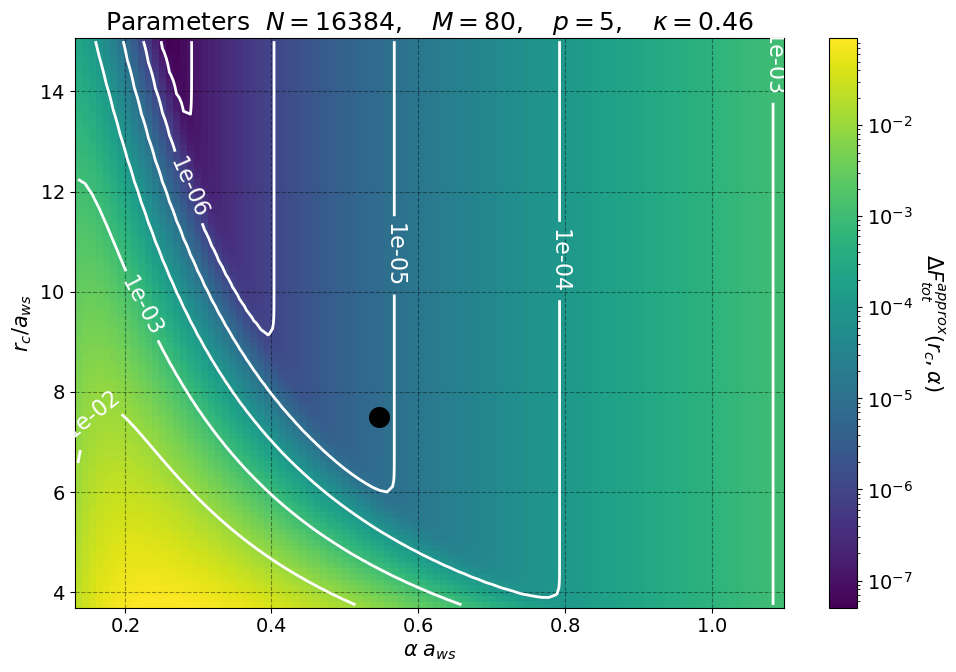

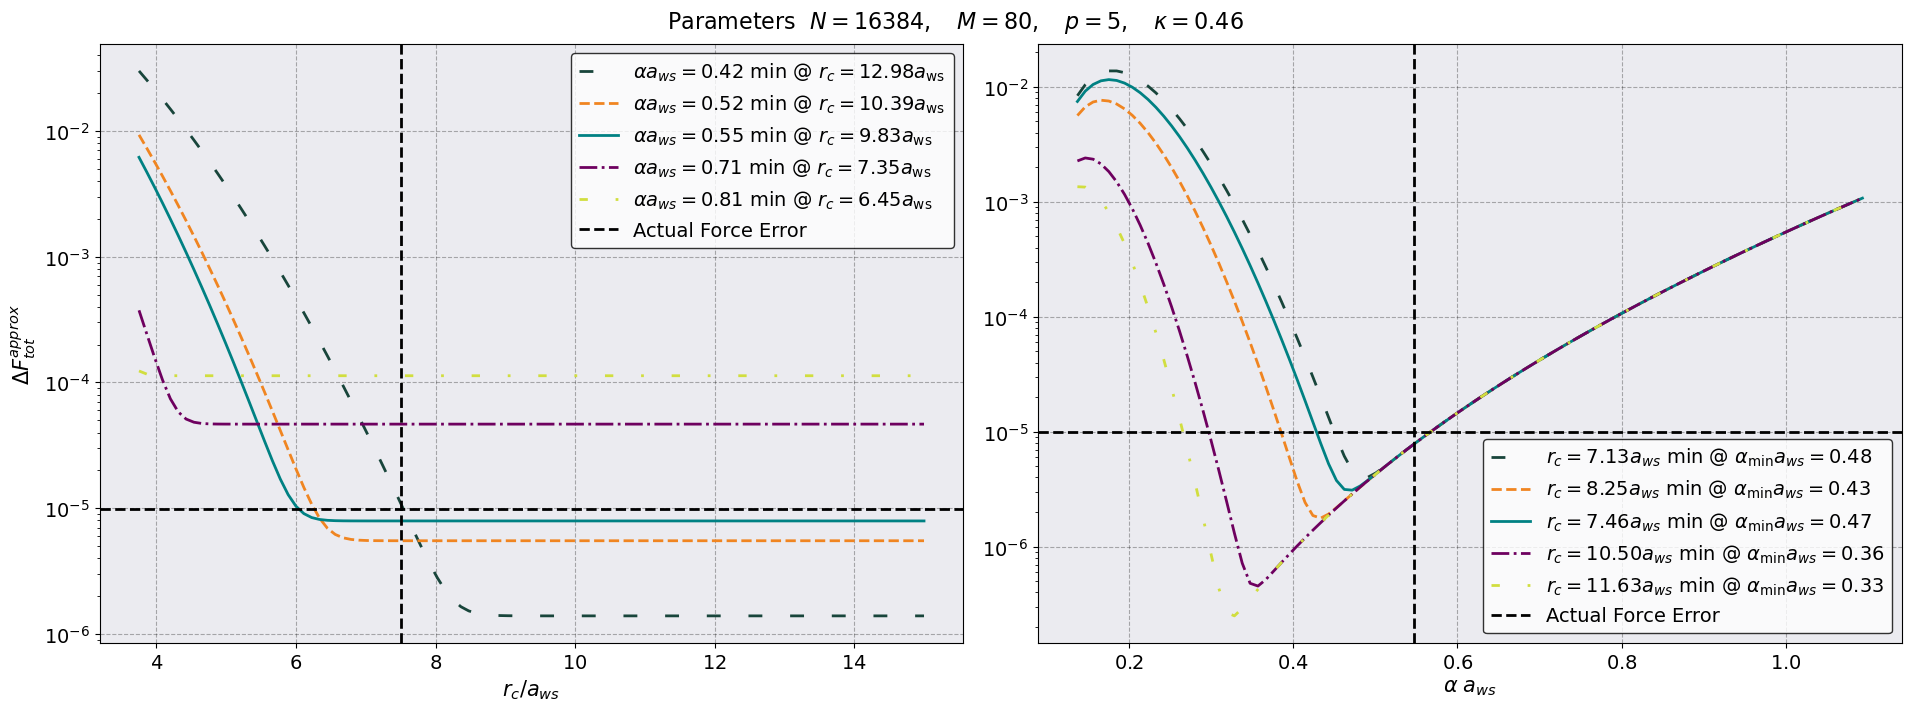

In [23]:
pre = PreProcess(input_file_name)
pre.setup(read_yaml=True)
pre.run(pppm_estimate = True)

In [3]:
# pre.run(pppm_estimate=True)
from sarkas.pppm_bayesian_optimization import compute_physical_bounds, FFT_FRIENDLY_MESHES

a_ws = pre.potential.a_ws
box_length = pre.potential.box_lengths.min()
N = pre.potential.total_num_ptcls

In [4]:
pp_cells = [3, 4, 5, 6]
pm_meshes = [32, 64, 80, 90, 100, 128,]
pm_caos = [4, 5, 6, 7]

rescaling_constant = pre.potential.QFactor * np.sqrt(3.0/(4.0 * np.pi)) / pre.potential.matrix[0,0,0]
rescaling_constant /= pre.potential.total_num_ptcls 


# --- Resolve mesh and CAO option lists --------------------------
mesh_options = list(pm_meshes) #if pm_meshes is not None else FFT_FRIENDLY_MESHES
cao_list     = list(pm_caos)   # if pm_caos   is not None else CAO_OPTIONS

# --- Derive rc bounds from pp_cells if provided -----------------
# pp_cells is the number of cells along one dimension, so
# rc = box_length / pp_cells.  Larger cell count => smaller rc.
rc_min_override = None
rc_max_override = None
if pp_cells is not None and len(pp_cells) > 0:
    pp_cells_arr = np.asarray(pp_cells, dtype=float)
    # box_length here is already dimensionless (L / a_ws)
    rc_min_override = box_length / float(pp_cells_arr.max())
    rc_max_override = box_length / float(pp_cells_arr.min())

# compute_physical_bounds receives dimensionless a_ws=1 and
# dimensionless box_length = L/a_ws, giving rc bounds in units of a_ws.
bounds = compute_physical_bounds(
    a_ws,
    box_length,
    mesh_options,
    cao_options=cao_list,
    rc_min_override=rc_min_override,
    rc_max_override=rc_max_override,
)

if pre.parameters.verbose:
    print(f"\nPhysical bounds:")
    print(f"  r_c   : [{bounds['rc_min']:.4e}, {bounds['rc_max']:.4e}]")
    print(f"  alpha : [{bounds['alpha_min']:.4e}, {bounds['alpha_max']:.4e}]")
    print(f"  M     : {bounds['M_options']}")
    print(f"  CAO   : {bounds['cao_options']}")



Physical bounds:
  r_c   : [3.9881e-08, 7.9763e-08]
  alpha : [2.0060e+07, 3.2095e+08]
  M     : [32, 64, 80, 90]
  CAO   : [4, 5, 6, 7]


In [5]:
from sarkas.pppm_bayesian_optimization import PPPMParameterCodec, make_analytical_error_fn, make_analytical_time_fn

codec = PPPMParameterCodec(bounds)

# Build analytical model closures.
# Note: a_ws is passed as the second argument so that the function
# can convert rc and alpha to the dimensionless units expected by
# the Sarkas force error routines (rc/a_ws, alpha*a_ws, etc.).
analytical_error_fn = make_analytical_error_fn(
    a_ws,
    pre.potential.screening_length,
    rescaling_constant,
    box_length,
)
analytical_time_fn = make_analytical_time_fn(N, box_length)

# Build high-fidelity evaluator (actual timing calls)
evaluate_fn = pre._make_hf_evaluator(rescaling_constant)


In [6]:
from sarkas.pppm_bayesian_optimization import analytical_warm_start
n_warm_rc = 10
n_warm_alpha = 10

X_warm, Y_time_warm, Y_error_warm = analytical_warm_start(
            codec, analytical_error_fn, analytical_time_fn, n_warm_rc, n_warm_alpha
        )

records = []
target_error = 1e-5

for i in range(X_warm.shape[0]):
    rc, alpha, M, cao = codec.decode(X_warm[i])
    records.append({
        "rc":          rc,
        "alpha":       alpha,
        "M":           M,
        "cao":         cao,
        "time":        float(Y_time_warm[i]),
        "force_error": float(Y_error_warm[i]),
        "fidelity":    "analytical",
        "feasible":    float(Y_error_warm[i]) <= target_error,
    })

if pre.parameters.verbose:
    n_feasible_warm = sum(1 for r in records if r["feasible"])
    print(f"  Feasible analytical points: {n_feasible_warm} / {len(records)}")


  Feasible analytical points: 1480 / 1600


In [7]:
from sarkas.pppm_bayesian_optimization import build_surrogate

# Initialise surrogates from analytical data.
# Negate time so the objective GP is maximised (BoTorch maximises EI).
Y_time_neg = -Y_time_warm  # shape (n, 1)

obj_model  = build_surrogate(X_warm, Y_time_neg,   codec.cat_dims)
con_model  = build_surrogate(X_warm, Y_error_warm, codec.cat_dims)


/home/luciano/anaconda3/envs/sarkas/lib/python3.9/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(
/home/luciano/anaconda3/envs/sarkas/lib/python3.9/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-07 to the diagonal
  warnings.warn(
/home/luciano/anaconda3/envs/sarkas/lib/python3.9/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-06 to the diagonal
  warnings.warn(


In [8]:
import torch

# Short-hands
bounds = codec.botorch_bounds  # shape (2, d)

# ── fine grid in normalised [0,1] space ────────────────────────────────────
Nr, Na = n_warm_rc * 10, n_warm_alpha * 10
rc_grid    = torch.linspace(bounds[0, 0], bounds[1, 0], Nr,    dtype=torch.double)
alpha_grid = torch.linspace(bounds[0, 1], bounds[1, 1], Na,    dtype=torch.double)
RC, ALPHA  = torch.meshgrid(rc_grid, alpha_grid, indexing='ij')  # (Nr, Na)
 
rc_flat    = RC.reshape(-1)
alpha_flat = ALPHA.reshape(-1)
 
# Fix one (M, cao) combination — index 1 = second mesh option, index 2 = third cao option.
# Change these to whichever categorical combination you want to inspect.
M_idx   = 1   # index into codec.M_options
cao_idx = 2   # index into codec.cao_options
M_fixed   = torch.full_like(rc_flat, float(M_idx))
cao_fixed = torch.full_like(rc_flat, float(cao_idx))
 
X_plot = torch.stack([rc_flat, alpha_flat, M_fixed, cao_fixed], dim=1)  # (Nr*Na, 4)
 

In [9]:
# ── predict in ORIGINAL scale via .posterior() ────────────────────────────
# model.posterior() applies the inverse outcome transform (un-standardises),
# so the mean is in the same units as the training targets.
with torch.no_grad():
    # Force error surrogate — values should be positive
    error_mean = con_model.posterior(X_plot).mean.squeeze()      # (Nr*Na,)
 
    # Time surrogate — targets were negated, so negate back to get positive times
    time_mean  = -obj_model.posterior(X_plot).mean.squeeze()     # (Nr*Na,)
 
error_2d = error_mean.reshape(Nr, Na).numpy()
time_2d  = time_mean.reshape(Nr, Na).numpy()
 

In [10]:
# ── decode normalised rc/alpha back to physical units for axis labels ──────
# RC and ALPHA are in normalised [0,1]; decode a single row/column is enough.
rc_phys    = RC[:, 0].numpy()    * (codec.rc_max    - codec.rc_min)    + codec.rc_min
alpha_phys = ALPHA[0, :].numpy() * (codec.alpha_max - codec.alpha_min) + codec.alpha_min
 
# Convert to the units your plot wants (divide rc by a_ws, multiply alpha by a_ws)
rc_ax    = rc_phys    / a_ws   # rc in units of a_ws (dimensionless)
alpha_ax = alpha_phys * a_ws   # alpha in units of 1/a_ws (dimensionless)
 
M_val   = codec.M_options[M_idx]
cao_val = codec.cao_options[cao_idx]

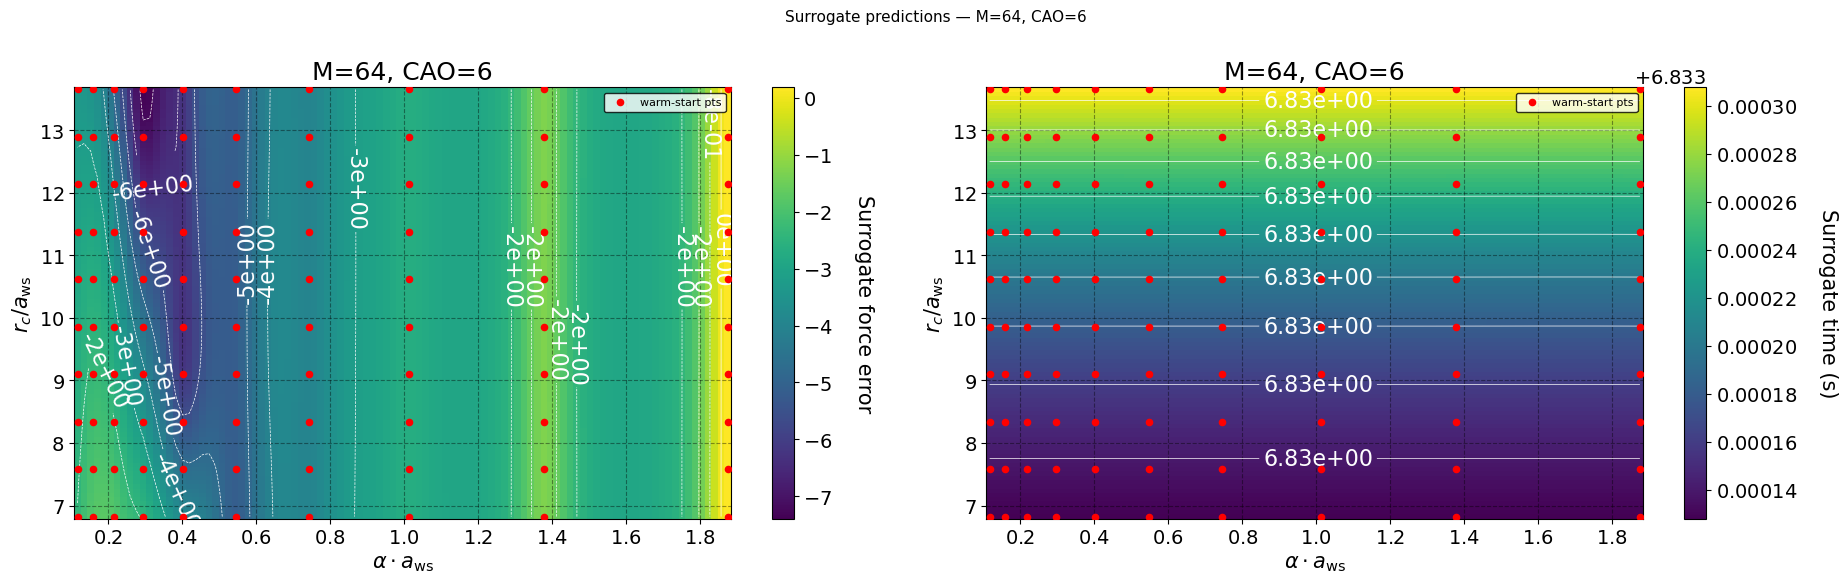

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(19, 6))
 
for ax, data, label, fmt in [
    (axes[0], error_2d, r"Surrogate force error",  "%1.0e"),
    (axes[1], time_2d,  r"Surrogate time (s)", "%1.2e"),
]:
    CS  = ax.pcolormesh(alpha_ax, rc_ax, data, shading='auto')
    CS2 = ax.contour(alpha_ax, rc_ax,  data, levels=10, colors='w', linewidths=0.5)
    ax.clabel(CS2, fmt=fmt, colors='w')
    fig.colorbar(CS, ax=ax).set_label(label, va='bottom', rotation=270, labelpad=15)
    ax.set_ylabel(r"$r_c / a_{\rm ws}$")
    ax.set_xlabel(r"$\alpha \cdot a_{\rm ws}$")
    ax.set_title(f"M={M_val}, CAO={cao_val}")
 
# ── also scatter the actual warm-start points for this (M, cao) slice ─────
mask = (X_warm[:, 2] == M_idx) & (X_warm[:, 3] == cao_idx)
if mask.any():
    rc_w    = X_warm[mask, 0].numpy() * (codec.rc_max - codec.rc_min) + codec.rc_min
    alpha_w = X_warm[mask, 1].numpy() * (codec.alpha_max - codec.alpha_min) + codec.alpha_min
    axes[0].scatter(alpha_w * a_ws, rc_w / a_ws,  c='r', s=20, zorder=5, label='warm-start pts')
    axes[0].legend(fontsize=8)
    axes[1].scatter(alpha_w * a_ws, rc_w / a_ws,  c='r', s=20, zorder=5, label='warm-start pts')
    axes[1].legend(fontsize=8)
 
fig.suptitle(
    f"Surrogate predictions — M={M_val}, CAO={cao_val}",
    fontsize=11,
)
fig.tight_layout()

Ok. The surrogate seems good enough. It is order of magnitude off, but at least is structure resembles the expected one. 

Let's now run the BO

In [13]:
from sarkas.pppm_bayesian_optimization import build_constrained_acqf
from botorch.optim import optimize_acqf_mixed 

# Track high-fidelity observations separately for surrogate updates
X_hf     = torch.empty((0, codec.n_dims), dtype=torch.double)
Y_time_hf  = torch.empty((0, 1),            dtype=torch.double)
Y_error_hf = torch.empty((0, 1),            dtype=torch.double)

# Surrogate is trained on log10(error) and log10(time), so the
# feasibility threshold must also be in log10 space.
log_target_error = np.log10(target_error)

best_feasible_time  = float("inf")
best_feasible_point = None

bounds = codec.botorch_bounds
fixed_features = codec.fixed_features_list()

n_bo_iterations = 20
n_restarts = 10
raw_samples = 256

# ---- Build acquisition function --------------------------------
# best_f: best negated time among points the GP believes are feasible
# We approximate feasibility using the constraint GP's posterior mean.
with torch.no_grad():
    # Evaluate constraint GP mean over all warm + HF inputs
    X_all_so_far = torch.cat([X_warm, X_hf], dim=0) if X_hf.shape[0] > 0 else X_warm
    con_post = con_model.posterior(X_all_so_far)
    con_mean = con_post.mean.squeeze()  # (n,)

    feasible_mask = con_mean <= log_target_error
    if feasible_mask.any():
        obj_mean = obj_model.posterior(X_all_so_far).mean.squeeze()
        best_f = float(obj_mean[feasible_mask].max())
    else:
        best_f = float(obj_model.posterior(X_all_so_far).mean.max())

acqf = build_constrained_acqf(obj_model, con_model, best_f, log_target_error)

# ---- Optimise acquisition over mixed space ----------------------

candidate, acq_value = optimize_acqf_mixed(
    acq_function=acqf,
    bounds=bounds,
    fixed_features_list=fixed_features,
    q=1,
    num_restarts=n_restarts,
    raw_samples=raw_samples,
    )

# ---- Decode and evaluate ---------------------------------------
rc, alpha, M, cao = codec.decode(candidate)
rc    = np.clip(rc,    codec.rc_min,    codec.rc_max)
alpha = np.clip(alpha, codec.alpha_min, codec.alpha_max)

print(f"candidate: rc: {rc:.4e}, alpha: {alpha:.4e}, M: {M}, CAO: {cao} — acq_value: {acq_value:.4e}")

/home/luciano/anaconda3/envs/sarkas/lib/python3.9/site-packages/botorch/optim/optimize.py:367: RuntimeWarning: Optimization failed in `gen_candidates_scipy` with the following warning(s):
[OptimizationWarning('Optimization failed within `scipy.optimize.minimize` with status 2 and message ABNORMAL_TERMINATION_IN_LNSRCH.')]
Trying again with a new set of initial conditions.
  warnings.warn(first_warn_msg, RuntimeWarning)
/home/luciano/anaconda3/envs/sarkas/lib/python3.9/site-packages/botorch/optim/optimize.py:389: RuntimeWarning: Optimization failed on the second try, after generating a new set of initial conditions.
  warnings.warn(
/home/luciano/anaconda3/envs/sarkas/lib/python3.9/site-packages/botorch/optim/optimize.py:367: RuntimeWarning: Optimization failed in `gen_candidates_scipy` with the following warning(s):
[OptimizationWarning('Optimization failed within `scipy.optimize.minimize` with status 2 and message ABNORMAL_TERMINATION_IN_LNSRCH.')]
Trying again with a new set of initi

candidate: rc: 7.9763e-08, alpha: 4.0793e+07, M: 32, CAO: 4 — acq_value: -1.7234e+00


In [14]:
time_val, error_val = evaluate_fn(rc, alpha, M, cao)

In [15]:
time_val, error_val

(4.013961309000001, 6.620239563521646e-05)

In [17]:

for iteration in range(n_bo_iterations):

    # ---- Build acquisition function --------------------------------
    # best_f: best negated time among points the GP believes are feasible
    # We approximate feasibility using the constraint GP's posterior mean.
    with torch.no_grad():
        # Evaluate constraint GP mean over all warm + HF inputs
        X_all_so_far = torch.cat([X_warm, X_hf], dim=0) if X_hf.shape[0] > 0 else X_warm
        con_post = con_model.posterior(X_all_so_far)
        con_mean = con_post.mean.squeeze()  # (n,)

        feasible_mask = con_mean <= log_target_error
        if feasible_mask.any():
            obj_mean = obj_model.posterior(X_all_so_far).mean.squeeze()
            best_f = float(obj_mean[feasible_mask].max())
        else:
            best_f = float(obj_model.posterior(X_all_so_far).mean.max())

    acqf = build_constrained_acqf(obj_model, con_model, best_f, log_target_error)

    # ---- Optimise acquisition over mixed space ----------------------
    try:
        candidate, acq_value = optimize_acqf_mixed(
            acq_function=acqf,
            bounds=bounds,
            fixed_features_list=fixed_features,
            q=1,
            num_restarts=n_restarts,
            raw_samples=raw_samples,
        )
    except Exception as e:
        if pre.parameters.verbose:
            print(f"  [iter {iteration+1}] Acquisition optimisation failed: {e}")
            print("  Falling back to random candidate.")
        candidate = torch.rand(1, codec.n_dims, dtype=torch.double)
        candidate[0, 2] = float(np.random.randint(0, len(codec.M_options)))
        candidate[0, 3] = float(np.random.randint(0, len(codec.cao_options)))
        candidate = candidate * (bounds[1] - bounds[0]) + bounds[0]

    # ---- Decode and evaluate ---------------------------------------
    rc, alpha, M, cao = codec.decode(candidate)
    rc    = np.clip(rc,    codec.rc_min,    codec.rc_max)
    alpha = np.clip(alpha, codec.alpha_min, codec.alpha_max)

    try:
        time_val, error_val = evaluate_fn(rc, alpha, M, cao)
    except Exception as e:
        if pre.parameters.verbose:
            print(f"  [iter {iteration+1}] MD evaluation failed: {e}. Skipping.")
        continue

    feasible = error_val <= target_error

    if pre.parameters.verbose:
        status = "✓ FEASIBLE" if feasible else "✗ infeasible"
        print(
            f"  [{iteration+1:3d}/{n_bo_iterations}] "
            f"rc={rc:.3e}  α={alpha:.4r}  M={M:3d}  cao={cao}  "
            f"err={error_val:.2e}  t={time_val:.4e}s  {status}"
        )

    if feasible and time_val < best_feasible_time:
        best_feasible_time  = time_val
        best_feasible_point = {"rc": rc, "alpha": alpha, "M": M, "cao": cao,
                                "time": time_val, "force_error": error_val}
        if pre.parameters.verbose:
            print(f"        *** New best: time={time_val:.4e}s ***")

    records.append({
        "rc":          rc,
        "alpha":       alpha,
        "M":           M,
        "cao":         cao,
        "time":        time_val,
        "force_error": error_val,
        "fidelity":    "high",
        "feasible":    feasible,
    })

    # ---- Update surrogates — store HF observations in log space ----
    x_new        = codec.encode(rc, alpha, M, cao)
    log_time_new = np.log10(max(time_val,  1e-30))
    log_err_new  = np.log10(max(error_val, 1e-30))
    y_time_new  = torch.tensor([[-log_time_new]], dtype=torch.double)  # negated log
    y_error_new = torch.tensor([[log_err_new]],   dtype=torch.double)

    X_hf       = torch.cat([X_hf,       x_new],        dim=0)
    Y_time_hf  = torch.cat([Y_time_hf,  y_time_new],   dim=0)
    Y_error_hf = torch.cat([Y_error_hf, y_error_new],  dim=0)

    # Rebuild surrogates using ALL data (warm + HF)
    X_all      = torch.cat([X_warm,      X_hf],       dim=0)
    Y_time_all = torch.cat([Y_time_neg,  Y_time_hf],  dim=0)
    Y_err_all  = torch.cat([Y_error_warm, Y_error_hf], dim=0)

    try:
        obj_model = build_surrogate(X_all, Y_time_all,  codec.cat_dims)
        con_model = build_surrogate(X_all, Y_err_all,   codec.cat_dims)
    except Exception as e:
        if pre.parameters.verbose:
            print(f"  [iter {iteration+1}] Surrogate refit failed: {e}. Keeping old model.")

# ------------------------------------------------------------------
# Summary
# ------------------------------------------------------------------
if pre.parameters.verbose:
    print("\n" + " Optimization Complete ".center(60, "="))
    if best_feasible_point:
        p = best_feasible_point
        print(
            f"  Best feasible configuration:\n"
            f"    rc={p['rc']:.4e}  alpha={p['alpha']:.4e}  "
            f"M={p['M']}  cao={p['cao']}\n"
            f"    force_error={p['force_error']:.4e}  time={p['time']:.4e}s"
        )
    else:
        print("  No feasible configuration found within budget.")
        print("  Consider increasing target_error or n_bo_iterations.")



/home/luciano/anaconda3/envs/sarkas/lib/python3.9/site-packages/botorch/optim/optimize.py:367: RuntimeWarning: Optimization failed in `gen_candidates_scipy` with the following warning(s):
[OptimizationWarning('Optimization failed within `scipy.optimize.minimize` with status 2 and message ABNORMAL_TERMINATION_IN_LNSRCH.')]
Trying again with a new set of initial conditions.
  warnings.warn(first_warn_msg, RuntimeWarning)
/home/luciano/anaconda3/envs/sarkas/lib/python3.9/site-packages/botorch/optim/optimize.py:367: RuntimeWarning: Optimization failed in `gen_candidates_scipy` with the following warning(s):
[OptimizationWarning('Optimization failed within `scipy.optimize.minimize` with status 2 and message ABNORMAL_TERMINATION_IN_LNSRCH.')]
Trying again with a new set of initial conditions.
  warnings.warn(first_warn_msg, RuntimeWarning)
/home/luciano/anaconda3/envs/sarkas/lib/python3.9/site-packages/botorch/optim/optimize.py:367: RuntimeWarning: Optimization failed in `gen_candidates_scip

  [  1/20] rc=0.000  α=40792352.4148  M= 32  cao=4  err=6.62e-05  t=3.9608e+00s  ✗ infeasible


/home/luciano/anaconda3/envs/sarkas/lib/python3.9/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(
/home/luciano/anaconda3/envs/sarkas/lib/python3.9/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-07 to the diagonal
  warnings.warn(
/home/luciano/anaconda3/envs/sarkas/lib/python3.9/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-06 to the diagonal
  warnings.warn(
/home/luciano/anaconda3/envs/sarkas/lib/python3.9/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-05 to the diagonal
  warnings.warn(


  [  2/20] rc=0.000  α=34881855.8957  M= 32  cao=4  err=4.43e-05  t=3.8863e+00s  ✗ infeasible


/home/luciano/anaconda3/envs/sarkas/lib/python3.9/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(
/home/luciano/anaconda3/envs/sarkas/lib/python3.9/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-07 to the diagonal
  warnings.warn(
/home/luciano/anaconda3/envs/sarkas/lib/python3.9/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-06 to the diagonal
  warnings.warn(
/home/luciano/anaconda3/envs/sarkas/lib/python3.9/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-05 to the diagonal
  warnings.warn(


...

/home/luciano/anaconda3/envs/sarkas/lib/python3.9/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(
/home/luciano/anaconda3/envs/sarkas/lib/python3.9/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-07 to the diagonal
  warnings.warn(
/home/luciano/anaconda3/envs/sarkas/lib/python3.9/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-06 to the diagonal
  warnings.warn(
/home/luciano/anaconda3/envs/sarkas/lib/python3.9/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-05 to the diagonal
  warnings.warn(


  [ 19/20] rc=0.000  α=69612457.1162  M= 80  cao=7  err=6.48e-08  t=1.6507e+00s  ✓ FEASIBLE


/home/luciano/anaconda3/envs/sarkas/lib/python3.9/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(
/home/luciano/anaconda3/envs/sarkas/lib/python3.9/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-07 to the diagonal
  warnings.warn(
/home/luciano/anaconda3/envs/sarkas/lib/python3.9/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-06 to the diagonal
  warnings.warn(
/home/luciano/anaconda3/envs/sarkas/lib/python3.9/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-05 to the diagonal
  warnings.warn(


  [ 20/20] rc=0.000  α=69700058.6345  M= 64  cao=5  err=5.70e-06  t=2.7518e+00s  ✓ FEASIBLE

================== Optimization Complete ===================
  Best feasible configuration:
    rc=4.3838e-08  alpha=9.3563e+07  M=80  cao=5
    force_error=9.9247e-06  time=7.9623e-01s


/home/luciano/anaconda3/envs/sarkas/lib/python3.9/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(
/home/luciano/anaconda3/envs/sarkas/lib/python3.9/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-07 to the diagonal
  warnings.warn(
/home/luciano/anaconda3/envs/sarkas/lib/python3.9/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-06 to the diagonal
  warnings.warn(


In [19]:
import pandas as pd

df = pd.DataFrame(records)

In [21]:
# Find the best feasible high-fidelity point
best_point = pre._extract_best_point(df, target_error)

msg = (
        f"\nOPTIMAL PPPM CONFIGURATION (BAYESIAN):\n"
        f"  Mesh: {best_point['M']} | CAO: {best_point['cao']} "
        f"| rc: {best_point['rc']:.4e}\n"
        f"  Ewald alpha: {best_point['alpha']:.4e} "
        f"| Force Error: {best_point['force_error']:.4e}\n"
        f"  Total Time: {best_point['time']:.4e} s"
    )

print(msg)


OPTIMAL PPPM CONFIGURATION (BAYESIAN):
  Mesh: 80 | CAO: 5 | rc: 4.3838e-08
  Ewald alpha: 9.3563e+07 | Force Error: 9.9247e-06
  Total Time: 7.9623e-01 s


In [22]:
pre.plot_bo_results(df, target_error)


Plots saved to: SarkasSimulations/qsp_cgs/PreProcessing/PPPM_Plots


In [ ]:

pre.timing_study_calculation(
    target_error=1e-6,
    pp_cells=pp_cells,
    pm_meshes=pm_meshes,
    pm_caos=pm_caos,
    method="bayesian"
)

In [ ]:
pareto_points, best_point = pre.find_pareto_optimal_configs(target_error=1e-6)

In [ ]:
postproc = PostProcess(input_file_name)
postproc.setup(read_yaml=True)

In [ ]:
# Equilibration check
from sarkas.tools.observables import Thermodynamics

therm = Thermodynamics()
therm.setup(postproc.parameters, phase = "equilibration")
therm.temp_energy_plot(postproc, )

In [ ]:
# Production check
therm = Thermodynamics()
therm.setup(postproc.parameters)
therm.temp_energy_plot(postproc)

In [ ]:
# Radial Distribution Function 
from sarkas.tools.observables import RadialDistributionFunction

rdf = RadialDistributionFunction()
rdf.setup(postproc.parameters)
rdf.compute()
# Grab HNC data for comparison
# hnc_r, hnc_gee, hnc_gei, hnc_gii = np.loadtxt('hnc_gall.out', unpack=True)

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(10,7))
# ax.plot(hnc_r , hnc_gee, label = 'hnc e-e RDF')
# ax.plot(hnc_r , hnc_gei, label = 'hnc e-p RDF')
# ax.plot(hnc_r , hnc_gii, label = 'hnc p-p RDF')
rdf.plot(scaling = postproc.species[0].a_ws, 
                  y = [('e-e RDF', "Mean"),
                       ('e-p RDF', "Mean"),
                       ('p-p RDF', "Mean")
                      ],
                  ax = ax, 
                  ls = '--')
ax.legend()
ax.set(xlim = (-0.2, 6), xlabel = r'$r/a_e$', ylabel = r"$g(r)$")

In [ ]:
from sarkas.tools.observables import ElectricCurrent
from sarkas.tools.transport import TransportCoefficients

In [ ]:
ec = ElectricCurrent()
ec.setup(postproc.parameters, no_slices = 4)
#ec.compute()
ec.parse()


In [ ]:
ec.dataframe

In [ ]:
tc = TransportCoefficients(postproc.parameters)
tc.electrical_conductivity(ec, "ElectricalConductivity")

In [ ]:
tc.conductivity_df

In [ ]:
rescaling = 1.0/ec.total_plasma_frequency
fig, ax = plt.subplots(1,1, figsize=(10,7))
ax.plot(tc.conductivity_df["Time"].iloc[:,0]*1e15, 
        tc.conductivity_df[("Electrical Conductivity", "Mean")] * rescaling,
       label = r'$\sigma$')

ax.plot(tc.conductivity_df["Time"].iloc[:,0]*1e15, tc.conductivity_df[("Electrical Conductivity", "Mean")].expanding().mean() * rescaling,
        ls = '--', label = r'Mov Avg')

ax.legend(ncol = 2)
ax.set(xlabel = r"$\tau$ [fs]",ylabel = r" $\sigma/\omega_p$")